# XGBoost Multiclass — Honest Pipeline (ROS & SMOTE Inside Pipeline)
## Resampling done INSIDE the pipeline — CV scores are now reliable

**All three experiments use the same original unbalanced training file:**
- `X_train_multiclass_safe.csv` — 45,324 rows, 147 features
- `y_train_multiclass.csv` — original labels, not resampled

| Experiment | Resampling | Where |
|---|---|---|
| Baseline | None | — |
| ROS | RandomOverSampler | Inside ImbPipeline |
| SMOTE | SMOTE | Inside ImbPipeline |

In [1]:
# !pip install xgboost imbalanced-learn shap scikit-learn pandas numpy matplotlib seaborn

## Cell 1 — Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import shap
%matplotlib inline

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder, label_binarize

print('All libraries imported successfully.')

All libraries imported successfully.


## Cell 2 — Configuration

In [3]:
DATA_DIR = r'C:\Users\I772586\OneDrive - SAP SE\Documents\XG BOOST SECOND\processed'
OUT_DIR  = r'C:\Users\I772586\OneDrive - SAP SE\Documents\XG BOOST SECOND\honest_pipeline'

os.makedirs(OUT_DIR, exist_ok=True)

matplotlib.rcParams.update({
    'font.family'       : 'Georgia',
    'font.size'         : 12,
    'axes.titlesize'    : 15,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 12,
    'axes.labelweight'  : 'bold',
    'xtick.labelsize'   : 11,
    'ytick.labelsize'   : 11,
    'figure.dpi'        : 100,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.edgecolor'    : '#cccccc',
    'axes.linewidth'    : 0.8,
    'axes.grid'         : True,
    'grid.alpha'        : 0.25,
    'grid.linestyle'    : '--',
    'grid.color'        : '#cccccc',
    'axes.facecolor'    : '#f9f9fb',
    'figure.facecolor'  : '#ffffff',
    'legend.framealpha' : 0.9,
    'legend.edgecolor'  : '#dddddd',
    'legend.fontsize'   : 10,
})

C_GREEN      = '#2d6a4f'
C_RED        = '#c1121f'
C_GREEN_SOFT = '#95d5b2'
C_RED_SOFT   = '#ffb4a2'
C_BLUE       = '#023e8a'
C_ORANGE     = '#e07a00'

print('Configuration done.')
print('DATA_DIR:', DATA_DIR)
print('OUT_DIR :', OUT_DIR)

Configuration done.
DATA_DIR: C:\Users\I772586\OneDrive - SAP SE\Documents\XG BOOST SECOND\processed
OUT_DIR : C:\Users\I772586\OneDrive - SAP SE\Documents\XG BOOST SECOND\honest_pipeline


## Cell 3 — Helper Functions

In [4]:
def plot_confusion_matrix_3(cm, title, save_path):
    n = 3
    fig, ax = plt.subplots(figsize=(7, 6))
    for i in range(n):
        for j in range(n):
            color = C_GREEN if i == j else C_RED_SOFT
            rect = mpatches.FancyBboxPatch(
                (j - 0.45, i - 0.45), 0.9, 0.9,
                boxstyle='round,pad=0.05', linewidth=0,
                facecolor=color, zorder=2)
            ax.add_patch(rect)
            ax.text(j, i, f'{cm[i][j]:,}',
                    ha='center', va='center',
                    fontsize=15, fontweight='bold',
                    color='white', zorder=3)
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, 2.5)
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(CLASS_NAMES, fontsize=11)
    ax.set_yticklabels(CLASS_NAMES, fontsize=11)
    ax.get_xticklabels()[0].set_color(C_RED)
    ax.get_xticklabels()[1].set_color(C_GREEN)
    ax.get_xticklabels()[2].set_color(C_ORANGE)
    ax.get_yticklabels()[0].set_color(C_RED)
    ax.get_yticklabels()[1].set_color(C_GREEN)
    ax.get_yticklabels()[2].set_color(C_ORANGE)
    ax.set_xlabel('Predicted', labelpad=10)
    ax.set_ylabel('Actual', labelpad=10)
    ax.set_title(title, pad=15)
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('#ffffff')
    correct_patch = mpatches.Patch(color=C_GREEN, label='Correct')
    wrong_patch   = mpatches.Patch(color=C_RED_SOFT, label='Wrong')
    ax.legend(handles=[correct_patch, wrong_patch],
              loc='upper center', bbox_to_anchor=(0.5, -0.12),
              ncol=2, frameon=False, fontsize=10)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()


def multiclass_pr_auc(y_true, y_prob):
    y_bin = label_binarize(y_true, classes=[0, 1, 2])
    return average_precision_score(y_bin, y_prob, average='macro')


def run_experiment(pipe, name, prefix):
    """
    Runs nested CV with the given pipeline.
    All experiments use the same X_train / y_train (original unbalanced).
    Resampling (if any) is applied inside the pipeline during each fold.
    """
    print('=' * 65)
    print(f'  EXPERIMENT: {name}')
    print('=' * 65)
    print(f'  Train shape : {X_train.shape}')
    print(f'  Class counts: {dict(zip(*np.unique(y_train, return_counts=True)))}')

    inner_cv = StratifiedKFold(n_splits=3,  shuffle=True, random_state=42)
    outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    search = RandomizedSearchCV(
        pipe, param_distributions=param_dist,
        n_iter=20, cv=inner_cv, scoring='f1_macro',
        n_jobs=-1, random_state=42, verbose=0)

    outer_f1, outer_roc, outer_pr = [], [], []
    conf_matrices = []

    print(f'\n  Running Nested CV (10 outer folds)...')
    print('  ' + '-' * 62)

    for fold, (tr_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train)):
        X_f, X_v = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_f, y_v = y_train[tr_idx], y_train[val_idx]

        # Pipeline applies resampling on X_f only — X_v never touched
        search.fit(X_f, y_f)
        best   = search.best_estimator_
        y_pred = best.predict(X_v)
        y_prob = best.predict_proba(X_v)

        f1  = f1_score(y_v, y_pred, average='macro')
        roc = roc_auc_score(y_v, y_prob, multi_class='ovr', average='macro')
        pr  = multiclass_pr_auc(y_v, y_prob)

        outer_f1.append(f1)
        outer_roc.append(roc)
        outer_pr.append(pr)
        conf_matrices.append(confusion_matrix(y_v, y_pred))

        print(f'  Fold {fold+1:2d}/10 | Macro F1: {f1:.4f} | '
              f'ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f}')

    print('\n  ' + '=' * 62)
    print(f'  Macro F1 : {np.mean(outer_f1):.4f} +/- {np.std(outer_f1):.4f}')
    print(f'  ROC-AUC  : {np.mean(outer_roc):.4f} +/- {np.std(outer_roc):.4f}')
    print(f'  PR-AUC   : {np.mean(outer_pr):.4f} +/- {np.std(outer_pr):.4f}')
    print('  ' + '=' * 62)

    mean_cm = np.round(np.mean(conf_matrices, axis=0)).astype(int)
    plot_confusion_matrix_3(
        mean_cm,
        f'CV Confusion Matrix — {name}',
        os.path.join(OUT_DIR, f'{prefix}_cv_cm.png'))
    print(f'  Saved: {prefix}_cv_cm.png')

    print(f'\n  Training final model on full training set...')
    search.fit(X_train, y_train)
    final_model = search.best_estimator_

    print('\n  Best Hyperparameters:')
    for k, v in search.best_params_.items():
        print(f'    {k.replace("clf__", ""):<22}: {v}')

    y_test_pred = final_model.predict(X_test)
    y_test_prob = final_model.predict_proba(X_test)

    test_f1  = f1_score(y_test_enc, y_test_pred, average='macro')
    test_roc = roc_auc_score(y_test_enc, y_test_prob,
                             multi_class='ovr', average='macro')
    test_pr  = multiclass_pr_auc(y_test_enc, y_test_prob)

    print(f'\n  ' + '=' * 62)
    print(f'  Test Results — {name}')
    print(f'  ' + '-' * 62)
    print(f'  Macro F1 : {test_f1:.4f}')
    print(f'  ROC-AUC  : {test_roc:.4f}')
    print(f'  PR-AUC   : {test_pr:.4f}')
    print(f'  ' + '=' * 62)
    print(f'\n  Per-Class Report:')
    print(classification_report(y_test_enc, y_test_pred,
                                target_names=CLASS_NAMES))

    cm_test = confusion_matrix(y_test_enc, y_test_pred)
    plot_confusion_matrix_3(
        cm_test,
        f'Test Confusion Matrix — {name}',
        os.path.join(OUT_DIR, f'{prefix}_test_cm.png'))
    print(f'  Saved: {prefix}_test_cm.png')

    return {
        'name'       : name,
        'prefix'     : prefix,
        'cv_f1'      : np.mean(outer_f1),
        'cv_f1_std'  : np.std(outer_f1),
        'cv_roc'     : np.mean(outer_roc),
        'cv_roc_std' : np.std(outer_roc),
        'cv_pr'      : np.mean(outer_pr),
        'cv_pr_std'  : np.std(outer_pr),
        'test_f1'    : test_f1,
        'test_roc'   : test_roc,
        'test_pr'    : test_pr,
        'final_model': final_model,
    }

print('Helper functions defined.')

Helper functions defined.


## Cell 4 — Load Data

In [5]:
# ── Training data — original unbalanced (same for ALL 3 experiments) ──
X_train    = pd.read_csv(os.path.join(DATA_DIR, 'X_train_multiclass_safe.csv'))
y_train_raw = pd.read_csv(os.path.join(DATA_DIR, 'y_train_multiclass.csv')).iloc[:, 0]

# ── Test data ──
X_test     = pd.read_csv(os.path.join(DATA_DIR, 'X_test_multiclass_safe.csv'))
y_test_raw = pd.read_csv(os.path.join(DATA_DIR, 'y_test_multiclass.csv')).iloc[:, 0]

# ── Label Encoder ──
le = LabelEncoder()
le.fit(['Bad', 'Good', 'Mixed'])
CLASS_NAMES = list(le.classes_)   # ['Bad', 'Good', 'Mixed']

y_train    = le.transform(y_train_raw)
y_test_enc = le.transform(y_test_raw)

print(f'Train shape : {X_train.shape}')
print(f'Test shape  : {X_test.shape}')
print(f'Class names : {CLASS_NAMES}   (Bad=0, Good=1, Mixed=2)')
print(f'Train labels: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Test labels : {dict(zip(*np.unique(y_test_enc, return_counts=True)))}')

# ── Hyperparameter search space ──
param_dist = {
    'clf__learning_rate'   : [0.01, 0.05, 0.1, 0.2, 0.3],
    'clf__max_depth'       : [3, 4, 5, 6, 7],
    'clf__subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'clf__n_estimators'    : [100, 200, 300],
    'clf__colsample_bytree': [0.6, 0.8, 1.0],
    'clf__min_child_weight': [1, 3, 5]
}

print('\nSetup complete. Ready to run experiments.')

Train shape : (45324, 147)
Test shape  : (11331, 147)
Class names : [np.str_('Bad'), np.str_('Good'), np.str_('Mixed')]   (Bad=0, Good=1, Mixed=2)
Train labels: {np.int64(0): np.int64(3819), np.int64(1): np.int64(28671), np.int64(2): np.int64(12834)}
Test labels : {np.int64(0): np.int64(955), np.int64(1): np.int64(7168), np.int64(2): np.int64(3208)}

Setup complete. Ready to run experiments.


---
## Experiment 1 — Baseline (No Resampling)
Plain pipeline — XGBoost only, no resampling.



  EXPERIMENT: Baseline (No Resampling)
  Train shape : (45324, 147)
  Class counts: {np.int64(0): np.int64(3819), np.int64(1): np.int64(28671), np.int64(2): np.int64(12834)}

  Running Nested CV (10 outer folds)...
  --------------------------------------------------------------
  Fold  1/10 | Macro F1: 0.4524 | ROC-AUC: 0.7494 | PR-AUC: 0.5259
  Fold  2/10 | Macro F1: 0.4639 | ROC-AUC: 0.7568 | PR-AUC: 0.5311
  Fold  3/10 | Macro F1: 0.4838 | ROC-AUC: 0.7569 | PR-AUC: 0.5376
  Fold  4/10 | Macro F1: 0.4814 | ROC-AUC: 0.7595 | PR-AUC: 0.5374
  Fold  5/10 | Macro F1: 0.4669 | ROC-AUC: 0.7459 | PR-AUC: 0.5176
  Fold  6/10 | Macro F1: 0.4573 | ROC-AUC: 0.7517 | PR-AUC: 0.5241
  Fold  7/10 | Macro F1: 0.4815 | ROC-AUC: 0.7514 | PR-AUC: 0.5252
  Fold  8/10 | Macro F1: 0.4580 | ROC-AUC: 0.7516 | PR-AUC: 0.5215
  Fold  9/10 | Macro F1: 0.4747 | ROC-AUC: 0.7601 | PR-AUC: 0.5366
  Fold 10/10 | Macro F1: 0.4928 | ROC-AUC: 0.7638 | PR-AUC: 0.5500

  Macro F1 : 0.4713 +/- 0.0128
  ROC-AUC  : 0.754

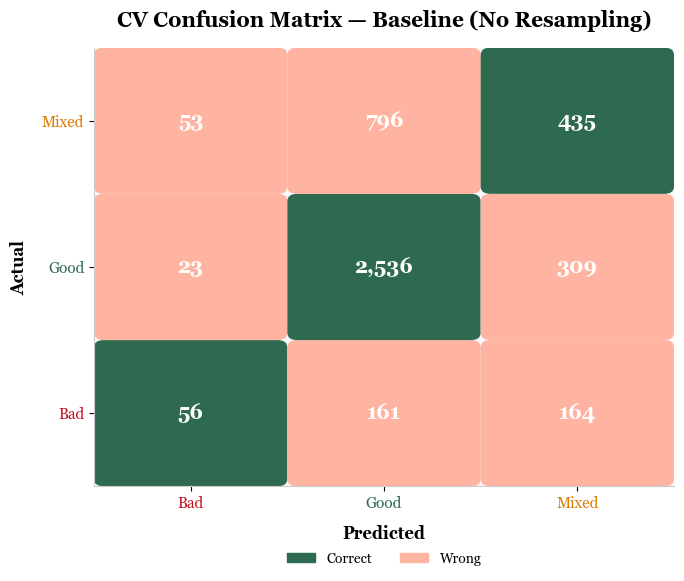

  Saved: hp_baseline_cv_cm.png

  Training final model on full training set...

  Best Hyperparameters:
    subsample             : 0.6
    n_estimators          : 200
    min_child_weight      : 1
    max_depth             : 7
    learning_rate         : 0.2
    colsample_bytree      : 0.6

  Test Results — Baseline (No Resampling)
  --------------------------------------------------------------
  Macro F1 : 0.4769
  ROC-AUC  : 0.7527
  PR-AUC   : 0.5320

  Per-Class Report:
              precision    recall  f1-score   support

         Bad       0.44      0.15      0.23       955
        Good       0.73      0.88      0.80      7168
       Mixed       0.49      0.35      0.40      3208

    accuracy                           0.67     11331
   macro avg       0.55      0.46      0.48     11331
weighted avg       0.63      0.67      0.64     11331



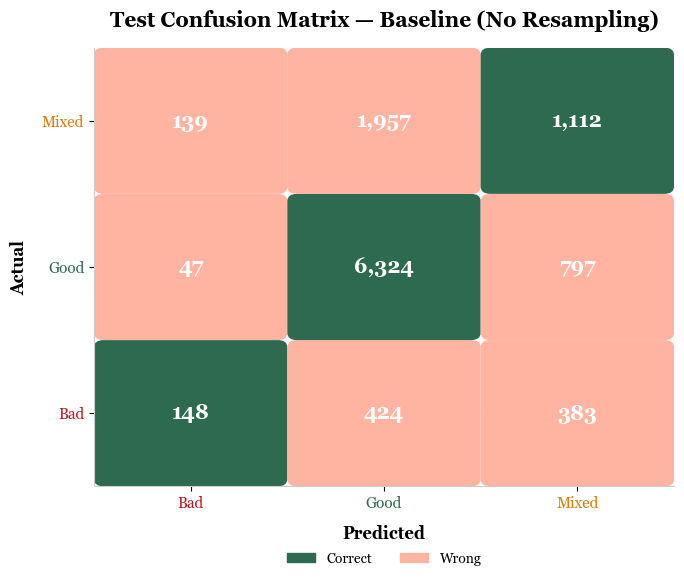

  Saved: hp_baseline_test_cm.png


In [6]:
pipe_baseline = Pipeline([
    ('clf', XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1))
])

results_baseline = run_experiment(
    pipe   = pipe_baseline,
    name   = 'Baseline (No Resampling)',
    prefix = 'hp_baseline'
)

---
## Experiment 2 — ROS Inside Pipeline
ImbPipeline: ROS runs on training fold only — validation fold stays original.


  EXPERIMENT: ROS Inside Pipeline
  Train shape : (45324, 147)
  Class counts: {np.int64(0): np.int64(3819), np.int64(1): np.int64(28671), np.int64(2): np.int64(12834)}

  Running Nested CV (10 outer folds)...
  --------------------------------------------------------------
  Fold  1/10 | Macro F1: 0.4921 | ROC-AUC: 0.7338 | PR-AUC: 0.5059
  Fold  2/10 | Macro F1: 0.5040 | ROC-AUC: 0.7453 | PR-AUC: 0.5177
  Fold  3/10 | Macro F1: 0.5122 | ROC-AUC: 0.7450 | PR-AUC: 0.5271
  Fold  4/10 | Macro F1: 0.5116 | ROC-AUC: 0.7510 | PR-AUC: 0.5299
  Fold  5/10 | Macro F1: 0.4982 | ROC-AUC: 0.7285 | PR-AUC: 0.5031
  Fold  6/10 | Macro F1: 0.5099 | ROC-AUC: 0.7401 | PR-AUC: 0.5095
  Fold  7/10 | Macro F1: 0.4963 | ROC-AUC: 0.7369 | PR-AUC: 0.5149
  Fold  8/10 | Macro F1: 0.4976 | ROC-AUC: 0.7406 | PR-AUC: 0.5187
  Fold  9/10 | Macro F1: 0.5005 | ROC-AUC: 0.7487 | PR-AUC: 0.5253
  Fold 10/10 | Macro F1: 0.5048 | ROC-AUC: 0.7509 | PR-AUC: 0.5321

  Macro F1 : 0.5027 +/- 0.0066
  ROC-AUC  : 0.7421 +/-

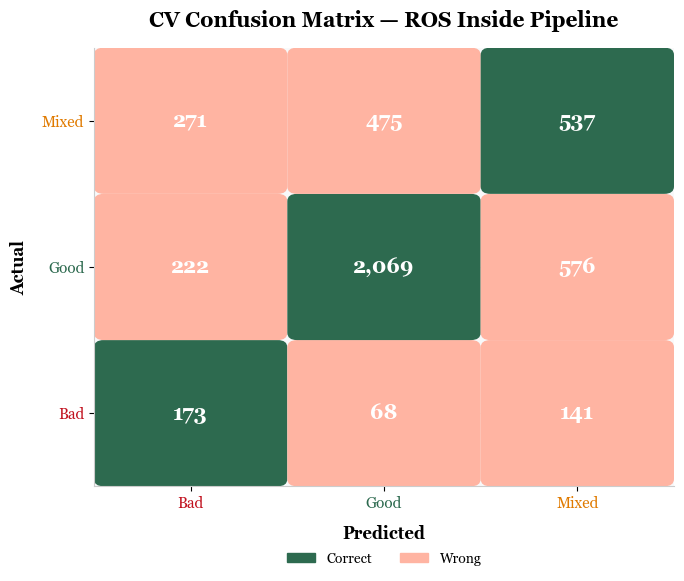

  Saved: hp_ros_cv_cm.png

  Training final model on full training set...

  Best Hyperparameters:
    subsample             : 0.6
    n_estimators          : 200
    min_child_weight      : 1
    max_depth             : 7
    learning_rate         : 0.2
    colsample_bytree      : 0.6

  Test Results — ROS Inside Pipeline
  --------------------------------------------------------------
  Macro F1 : 0.5056
  ROC-AUC  : 0.7423
  PR-AUC   : 0.5261

  Per-Class Report:
              precision    recall  f1-score   support

         Bad       0.26      0.47      0.34       955
        Good       0.79      0.72      0.75      7168
       Mixed       0.43      0.42      0.43      3208

    accuracy                           0.61     11331
   macro avg       0.50      0.54      0.51     11331
weighted avg       0.65      0.61      0.63     11331



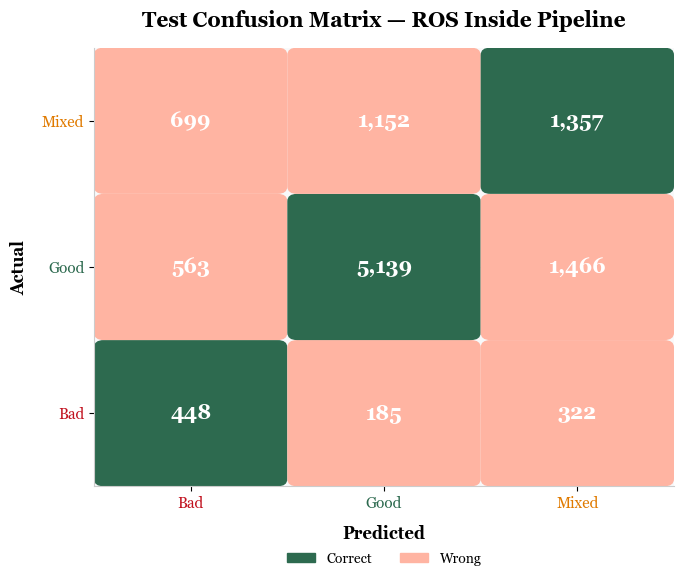

  Saved: hp_ros_test_cm.png


In [7]:
pipe_ros = ImbPipeline([
    ('ros', RandomOverSampler(random_state=42)),
    ('clf', XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1))
])

results_ros = run_experiment(
    pipe   = pipe_ros,
    name   = 'ROS Inside Pipeline',
    prefix = 'hp_ros'
)

---
## Experiment 3 — SMOTE Inside Pipeline
ImbPipeline: SMOTE runs on training fold only — validation fold stays original.


  EXPERIMENT: SMOTE Inside Pipeline
  Train shape : (45324, 147)
  Class counts: {np.int64(0): np.int64(3819), np.int64(1): np.int64(28671), np.int64(2): np.int64(12834)}

  Running Nested CV (10 outer folds)...
  --------------------------------------------------------------
  Fold  1/10 | Macro F1: 0.4758 | ROC-AUC: 0.7305 | PR-AUC: 0.5069
  Fold  2/10 | Macro F1: 0.4885 | ROC-AUC: 0.7361 | PR-AUC: 0.5153
  Fold  3/10 | Macro F1: 0.5001 | ROC-AUC: 0.7367 | PR-AUC: 0.5104
  Fold  4/10 | Macro F1: 0.5007 | ROC-AUC: 0.7435 | PR-AUC: 0.5228
  Fold  5/10 | Macro F1: 0.4934 | ROC-AUC: 0.7294 | PR-AUC: 0.5053
  Fold  6/10 | Macro F1: 0.4815 | ROC-AUC: 0.7385 | PR-AUC: 0.5110
  Fold  7/10 | Macro F1: 0.4896 | ROC-AUC: 0.7303 | PR-AUC: 0.5044
  Fold  8/10 | Macro F1: 0.4953 | ROC-AUC: 0.7379 | PR-AUC: 0.5107
  Fold  9/10 | Macro F1: 0.4924 | ROC-AUC: 0.7413 | PR-AUC: 0.5157
  Fold 10/10 | Macro F1: 0.4962 | ROC-AUC: 0.7422 | PR-AUC: 0.5170

  Macro F1 : 0.4913 +/- 0.0075
  ROC-AUC  : 0.7367 +

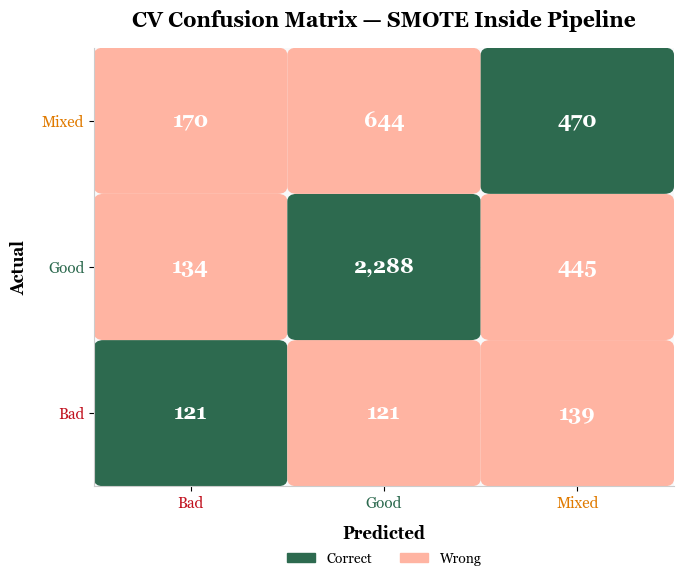

  Saved: hp_smote_cv_cm.png

  Training final model on full training set...

  Best Hyperparameters:
    subsample             : 1.0
    n_estimators          : 200
    min_child_weight      : 1
    max_depth             : 6
    learning_rate         : 0.3
    colsample_bytree      : 0.8

  Test Results — SMOTE Inside Pipeline
  --------------------------------------------------------------
  Macro F1 : 0.5010
  ROC-AUC  : 0.7374
  PR-AUC   : 0.5189

  Per-Class Report:
              precision    recall  f1-score   support

         Bad       0.33      0.31      0.32       955
        Good       0.74      0.82      0.78      7168
       Mixed       0.46      0.36      0.40      3208

    accuracy                           0.65     11331
   macro avg       0.51      0.50      0.50     11331
weighted avg       0.63      0.65      0.64     11331



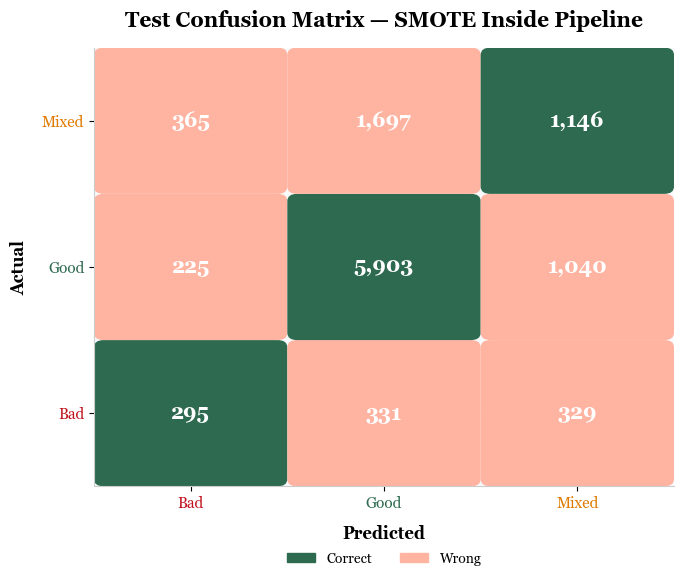

  Saved: hp_smote_test_cm.png


In [8]:
pipe_smote = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1))
])

results_smote = run_experiment(
    pipe   = pipe_smote,
    name   = 'SMOTE Inside Pipeline',
    prefix = 'hp_smote'
)

---
## Comparison — All Three Experiments

Experiment                        CV F1   CV ROC    CV PR   Test F1  Test ROC
---------------------------------------------------------------------------
Baseline (No Resampling)       0.4713   0.7547   0.5307   0.4769    0.7527
ROS Inside Pipeline            0.5027   0.7421   0.5184   0.5056    0.7423
SMOTE Inside Pipeline          0.4913   0.7367   0.5120   0.5010    0.7374

NOTE: CV scores are now HONEST — resampling done inside pipeline.


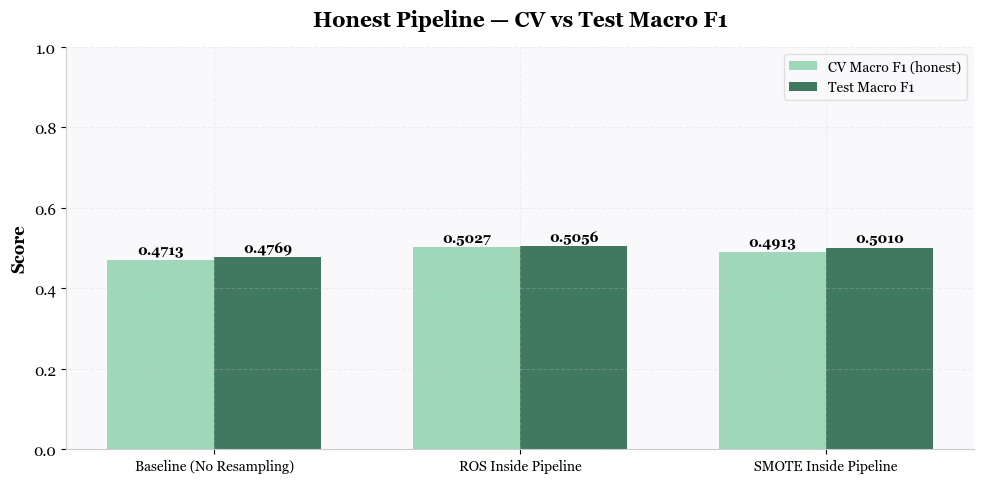

Saved: hp_comparison.png


In [ ]:
all_results = []
for var_name in ['results_baseline', 'results_ros', 'results_smote']:
    if var_name in dir():
        all_results.append(eval(var_name))

print('=' * 75)
print(f'{"Experiment":<30} {"CV F1":>8} {"CV ROC":>8} {"CV PR":>8} '
      f'{"Test F1":>9} {"Test ROC":>9}')
print('-' * 75)
for r in all_results:
    print(f'{r["name"]:<30} '
          f'{r["cv_f1"]:.4f}   '
          f'{r["cv_roc"]:.4f}   '
          f'{r["cv_pr"]:.4f}   '
          f'{r["test_f1"]:.4f}    '
          f'{r["test_roc"]:.4f}')
print('=' * 75)
print('\nNOTE: CV scores are now HONEST — resampling done inside pipeline.')

names     = [r['name'] for r in all_results]
cv_f1s    = [r['cv_f1']   for r in all_results]
test_f1s  = [r['test_f1'] for r in all_results]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, cv_f1s,   width, label='CV Macro F1 (honest)',  color='#95d5b2', alpha=0.9)
bars2 = ax.bar(x + width/2, test_f1s, width, label='Test Macro F1',          color='#2d6a4f', alpha=0.9)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Pipeline — CV vs Test Macro F1', pad=15)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'hp_comparison.png'), dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: hp_comparison.png')

---
## SHAP Analysis — Best Model
Change `model_for_shap` to whichever experiment scored highest on Test F1.

In [10]:
# Change to results_ros or results_smote based on which scored best
model_for_shap = results_ros

final_model = model_for_shap['final_model']
xgb_model   = final_model.named_steps['clf']
exp_name    = model_for_shap['name']
exp_prefix  = model_for_shap['prefix']

X_test_f32 = X_test.astype(np.float32)

print(f'Running SHAP on: {exp_name}')
print('Computing SHAP values...')

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_f32)

if isinstance(shap_values, list):
    sv_bad   = shap_values[0]
    sv_good  = shap_values[1]
    sv_mixed = shap_values[2]
else:
    sv_bad   = shap_values[:, :, 0]
    sv_good  = shap_values[:, :, 1]
    sv_mixed = shap_values[:, :, 2]

print('SHAP values computed.')

Running SHAP on: ROS Inside Pipeline
Computing SHAP values...
SHAP values computed.


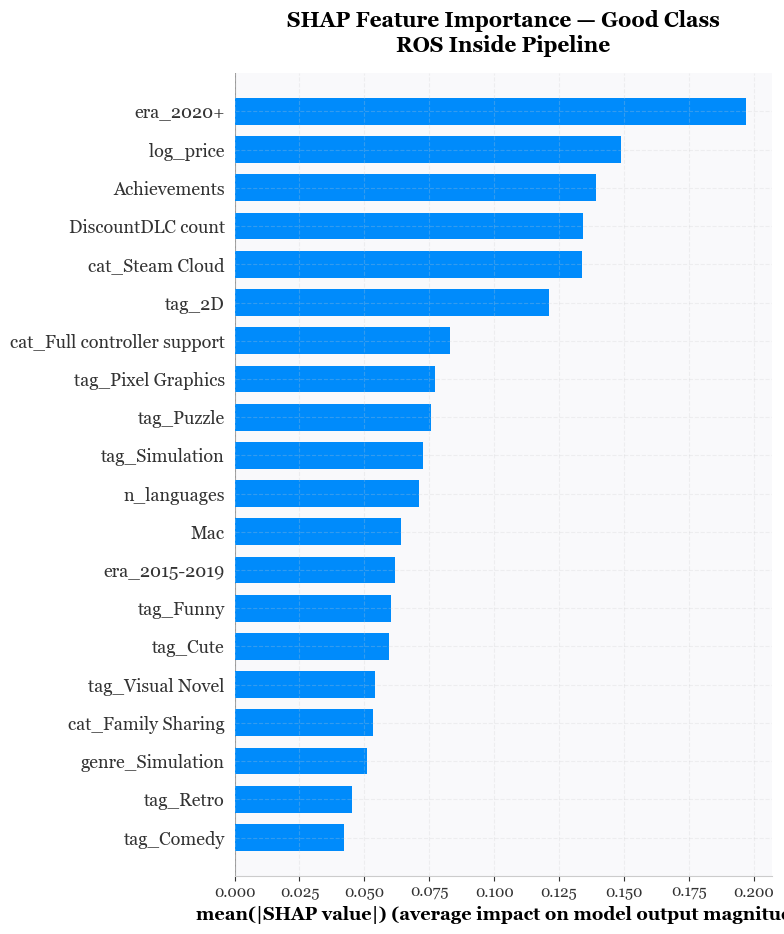

Saved: hp_ros_shap_bar_good.png


In [11]:
plt.figure(figsize=(9, 7))
shap.summary_plot(sv_good, X_test, plot_type='bar', max_display=20, show=False)
plt.title(f'SHAP Feature Importance — Good Class\n{exp_name}', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'{exp_prefix}_shap_bar_good.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {exp_prefix}_shap_bar_good.png')

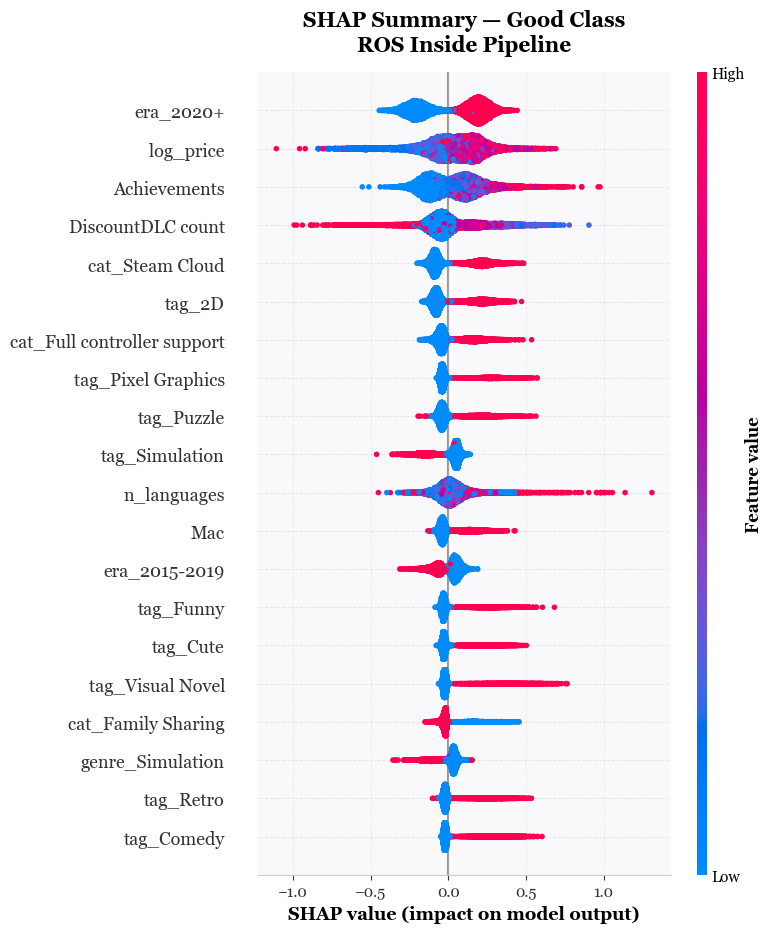

Saved: hp_ros_shap_summary_good.png


In [12]:
plt.figure(figsize=(10, 8))
shap.summary_plot(sv_good, X_test, max_display=20, show=False)
plt.title(f'SHAP Summary — Good Class\n{exp_name}', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'{exp_prefix}_shap_summary_good.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved: {exp_prefix}_shap_summary_good.png')

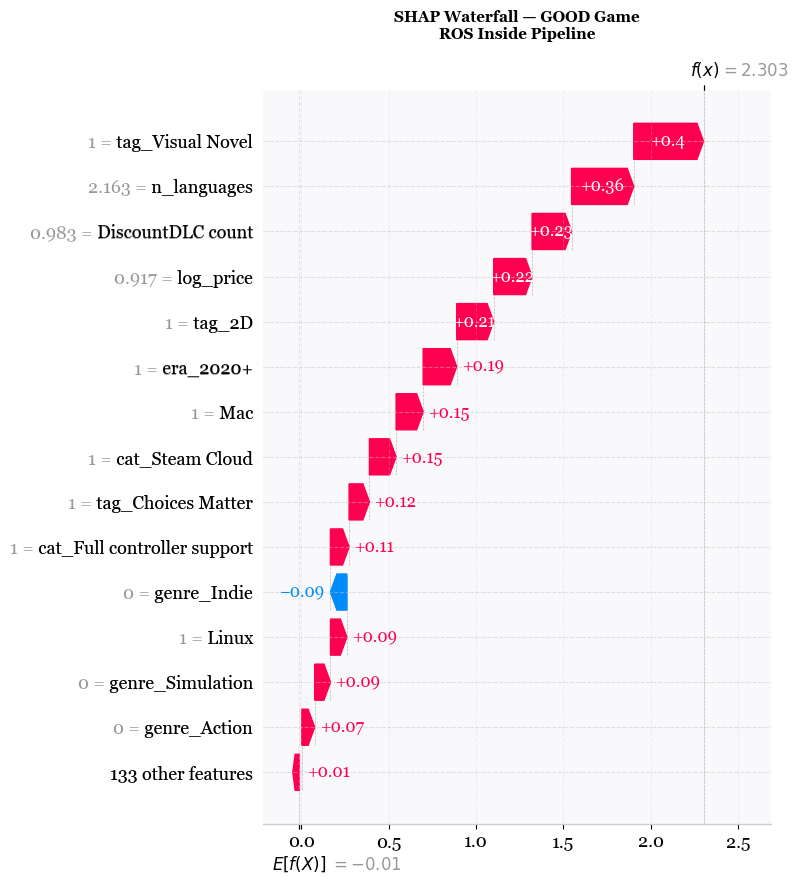

Saved: hp_ros_shap_waterfall_good.png


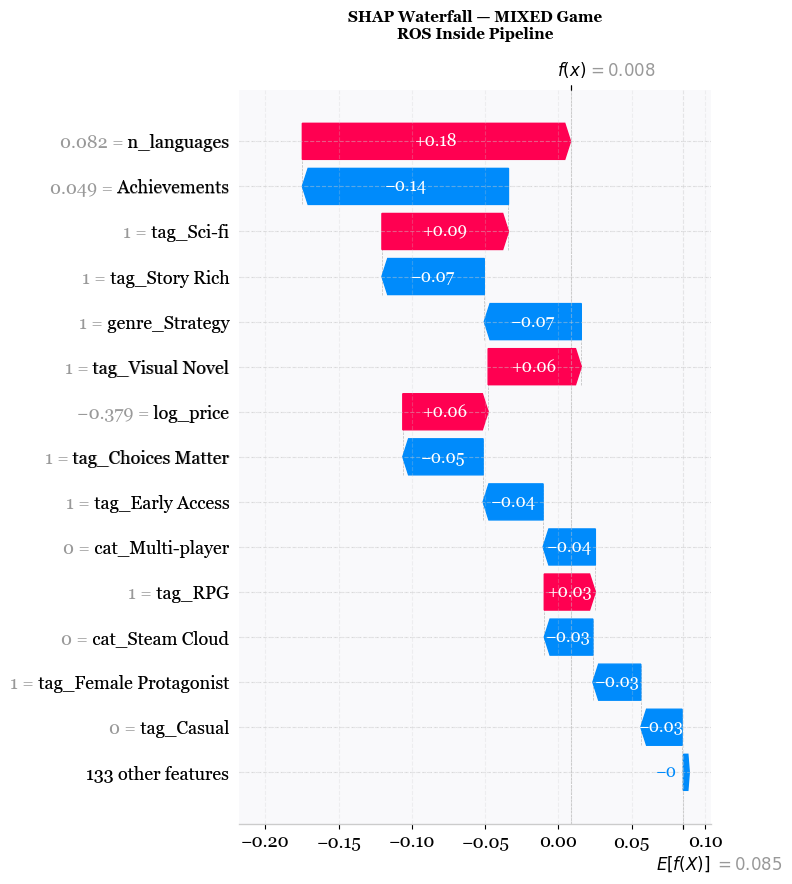

Saved: hp_ros_shap_waterfall_mixed.png


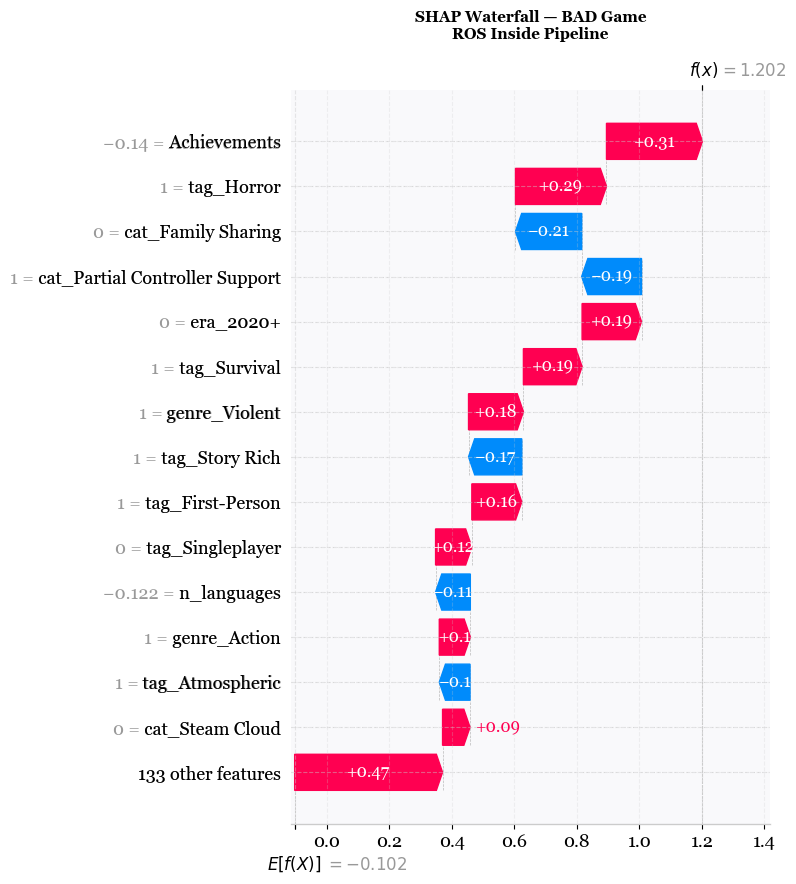

Saved: hp_ros_shap_waterfall_bad.png

All outputs saved to: C:\Users\I772586\OneDrive - SAP SE\Documents\XG BOOST SECOND\honest_pipeline


In [13]:
y_test_pred_local = final_model.predict(X_test)

explainer2 = shap.TreeExplainer(xgb_model)
shap_exp   = explainer2(X_test_f32)

good_idx  = next(i for i in range(len(y_test_enc)) if y_test_enc[i]==1 and y_test_pred_local[i]==1)
mixed_idx = next(i for i in range(len(y_test_enc)) if y_test_enc[i]==2 and y_test_pred_local[i]==2)
bad_idx   = next(i for i in range(len(y_test_enc)) if y_test_enc[i]==0 and y_test_pred_local[i]==0)

for idx, label, class_idx in [(good_idx,'GOOD',1),(mixed_idx,'MIXED',2),(bad_idx,'BAD',0)]:
    plt.figure()
    exp_single = shap.Explanation(
        values        = shap_exp.values[idx, :, class_idx],
        base_values   = shap_exp.base_values[idx, class_idx],
        data          = shap_exp.data[idx],
        feature_names = shap_exp.feature_names
    )
    shap.plots.waterfall(exp_single, max_display=15, show=False)
    plt.title(f'SHAP Waterfall — {label} Game\n{exp_name}', pad=15, fontsize=11)
    plt.tight_layout()
    fname = f'{exp_prefix}_shap_waterfall_{label.lower()}.png'
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=150,
                bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()
    print(f'Saved: {fname}')

print(f'\nAll outputs saved to: {OUT_DIR}')